# AgriBot v2 — Fine-Tuned FLAN-T5-base + RAG with Guardrails

**Course:** WQF7007 Natural Language Processing | University of Malaya, Master of Data Science  
**Alignment:** UN SDG 2 — Zero Hunger  
**Date:** 18 April 2026

---

## What's New in Version 2

| Dimension | Version 1 | Version 2 |
|-----------|-----------|----------|
| Model | FLAN-T5-small (77M) | FLAN-T5-base (250M) |
| Training data | 3,044 records (1 source) | ~25,000 records (3 sources) |
| Architecture | Fine-tuning only | Fine-tuning + RAG |
| Safety | None | 2-layer guardrails |
| Evaluation | ROUGE + BLEU | ROUGE + BLEU + BERTScore |

## Pipeline Overview

```
3 Data Sources
     │
     ▼
[1] EDA & Analysis
     │
     ▼
[2] Augmentation & Preprocessing
     │
     ▼
[3] Tokenization (FLAN-T5-base)
     │
     ▼
[4] Fine-tuning (Seq2SeqTrainer)
     │
     ▼
[5] RAG (sentence-transformers + FAISS)
     │
     ▼
[6] Guardrails (Intent + Retrieval)
     │
     ▼
[7] Evaluation
     │
     ▼
[8] Deployment (Streamlit)
```

---
## Section 0 — Environment Setup

In [1]:
# Install required packages (safe to re-run — skips already installed)
!pip install -q transformers datasets evaluate rouge_score sacrebleu sentencepiece accelerate
!pip install -q sentence-transformers faiss-cpu
!pip install -q bert_score
!pip install -q streamlit

In [1]:
import os
import re
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    GenerationConfig,
)
import evaluate
from sentence_transformers import SentenceTransformer
import faiss

# ── GPU check ──────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found — training will be very slow on CPU.")

ModuleNotFoundError: No module named 'evaluate'

In [ ]:
# Mount Google Drive (Colab) — skip if running locally
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print("Not on Colab — using local paths.")

print(f"Running on Colab: {ON_COLAB}")

Mounted at /content/drive
Running on Colab: True


In [ ]:
# ── Path & Model Configuration  ────────────────────────────────────────────
if ON_COLAB:
    DATASET_DIR = '/content/drive/MyDrive/1_UM/1_NLP Project/dataset'
    OUTPUT_DIR  = '/content/drive/MyDrive/1_UM/1_NLP Project/flan-t5-agribot-v2'
    INDEX_PATH  = '/content/drive/MyDrive/1_UM/1_NLP Project/agribot_faiss.index'
    DOCS_PATH   = '/content/drive/MyDrive/1_UM/1_NLP Project/agribot_docs.pkl'
else:
    DATASET_DIR = '../dataset'
    OUTPUT_DIR  = '../flan-t5-agribot-v2'
    INDEX_PATH  = '../agribot_faiss.index'
    DOCS_PATH   = '../agribot_docs.pkl'

# ── Model names ─────────────────────────────────────────────────────────────
BASE_MODEL  = 'google/flan-t5-base'
EMBED_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'

# ── Tokenisation limits ─────────────────────────────────────────────────────
MAX_INPUT_LEN  = 256
MAX_TARGET_LEN = 128
MAX_RAG_INPUT  = 512

# ── Training hyperparameters ────────────────────────────────────────────────
TRAIN_EPOCHS  = 5
BATCH_SIZE    = 16

# 3e-4 (v1) worked for small (77M) but causes fp16 NaN on base (250M):
# larger model → larger activations → forward pass overflows fp16 on T4.
# 1e-4 is the standard safe ceiling for base-size T5 fine-tuning.
LEARNING_RATE = 1e-4

WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.05
MAX_GRAD_NORM = 1.0   # gradient clipping — extra safety net against overflow

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Configuration loaded.")
print(f"  Base model   : {BASE_MODEL}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Max grad norm: {MAX_GRAD_NORM}")


---
## Section 1 — Data Sources & Exploratory Data Analysis

Three datasets are combined to form a richer, more diverse knowledge base:

| # | Source | Specialisation | Records |
|---|--------|---------------|---------|
| A | **AgroQA** | Crop-specific practical advice (cassava, maize, beans) | ~3,044 |
| B | **FAO Manual QA** | Agricultural extension methodology & institutional knowledge | ~38 |
| C | **Agriculture-QA** | Broad general agriculture (soil, irrigation, organic farming …) | ~22,615 |

After augmentation we get **A + B + C**: crop-level detail, expert extension principles, and wide topical coverage.

In [ ]:
# ── Load raw datasets ───────────────────────────────────────────────────────
df_A = pd.read_csv(os.path.join(DATASET_DIR, 'agroqa_dataset.csv'))
df_B = pd.read_csv(os.path.join(DATASET_DIR, 'FAO_Manual_QA.csv'))
df_C = pd.read_csv(os.path.join(DATASET_DIR, 'agriculture-qa-english-only.csv'))

print("Raw shapes:")
print(f"  Source A (AgroQA)        : {df_A.shape}  — columns: {list(df_A.columns)}")
print(f"  Source B (FAO Manual)    : {df_B.shape}  — columns: {list(df_B.columns)}")
print(f"  Source C (Agriculture-QA): {df_C.shape}  — columns: {list(df_C.columns)}")

Raw shapes:
  Source A (AgroQA)        : (3044, 3)  — columns: ['Crop', 'Question', 'Answer']
  Source B (FAO Manual)    : (38, 3)  — columns: ['Crop', 'Question', 'Answer']
  Source C (Agriculture-QA): (22615, 3)  — columns: ['Unnamed: 0', 'question', 'answers']


In [ ]:
# ── Source A: AgroQA ────────────────────────────────────────────────────────
print("=" * 60)
print("SOURCE A — AgroQA  (crop-specific practical advice)")
print("=" * 60)
print(df_A.head(4).to_string(index=False))
print(f"\nNull values:\n{df_A.isnull().sum()}")
print(f"\nCrop distribution:")
print(df_A['Crop'].value_counts())

df_A['q_len'] = df_A['Question'].str.split().str.len()
df_A['a_len'] = df_A['Answer'].str.split().str.len()
print(f"\nQuestion length (words): mean={df_A['q_len'].mean():.1f}, max={df_A['q_len'].max()}")
print(f"Answer   length (words): mean={df_A['a_len'].mean():.1f}, max={df_A['a_len'].max()}")

SOURCE A — AgroQA  (crop-specific practical advice)
   Crop                                                                Question                                                                   Answer
  maize           Apart from hand weeding, what other method used to weed maize                                          Machinery weeders are available
  beans Apart from insecticide, what other method used to control bean weevils? Use resistant verities and increase on water availability for crop vigor
  maize          Apart from sun drying which other method used for drying maize                          Use tarpaulins or cemented floor free from dust
cassava       Apart from sun drying, what other method can I use to dry cassava                                                             Solar driers

Null values:
Crop        0
Question    0
Answer      1
dtype: int64

Crop distribution:
Crop
cassava    1074
maize       724
beans       685
general     561
Name: count, dtype: int64

In [ ]:
# ── Source B: FAO Manual ────────────────────────────────────────────────────
print("=" * 60)
print("SOURCE B — FAO Manual  (extension methodology & policy)")
print("=" * 60)
print(df_B.head(4).to_string(index=False))
print(f"\nNull values:\n{df_B.isnull().sum()}")

df_B['q_len'] = df_B['Question'].str.split().str.len()
df_B['a_len'] = df_B['Answer'].str.split().str.len()
print(f"\nQuestion length (words): mean={df_B['q_len'].mean():.1f}, max={df_B['q_len'].max()}")
print(f"Answer   length (words): mean={df_B['a_len'].mean():.1f}, max={df_B['a_len'].max()}")

SOURCE B — FAO Manual  (extension methodology & policy)
   Crop                                               Question                                                                                                                                                                                                                                                                                                                                                                                                                               Answer
general               Why is agricultural extension important?                                         Extension is essentially the means by which new knowledge and ideas are introduced into rural areas to improve the lives of farmers and their families. Without agricultural extension, farmers would lack access to the support and services required to improve their agriculture and other productive activities. Its three main elements are: Knowledge, Communic

In [ ]:
# ── Source C: Agriculture-QA ────────────────────────────────────────────────
print("=" * 60)
print("SOURCE C — Agriculture-QA  (broad general agriculture)")
print("=" * 60)
print(df_C.head(4).to_string(index=False))
print(f"\nNull values:\n{df_C.isnull().sum()}")

# Identify correct column names (may vary)
q_col = [c for c in df_C.columns if 'question' in c.lower()][0]
a_col = [c for c in df_C.columns if 'answer' in c.lower()][0]
print(f"\nDetected columns → question: '{q_col}', answer: '{a_col}'")

df_C['q_len'] = df_C[q_col].astype(str).str.split().str.len()
df_C['a_len'] = df_C[a_col].astype(str).str.split().str.len()
print(f"\nQuestion length (words): mean={df_C['q_len'].mean():.1f}, max={df_C['q_len'].max()}")
print(f"Answer   length (words): mean={df_C['a_len'].mean():.1f}, max={df_C['a_len'].max()}")

SOURCE C — Agriculture-QA  (broad general agriculture)
 Unnamed: 0                                          question                                                                                                    answers
          0        why is crop rotation important in farming?          This helps to prevent soil erosion and depletion, and can also help to control pests and diseases
          1 What farming practice helps prevent soil erosion?                                                                                              Crop Rotation
          2                             what is crop rotation Crop rotation is the practice of growing a series of different crops in the same area over several seasons
          3     what are the different methods of irrigation?                                              surface irrigation, drip irrigation, and sprinkler irrigation

Null values:
Unnamed: 0    0
question      0
answers       0
dtype: int64

Detected columns → quest

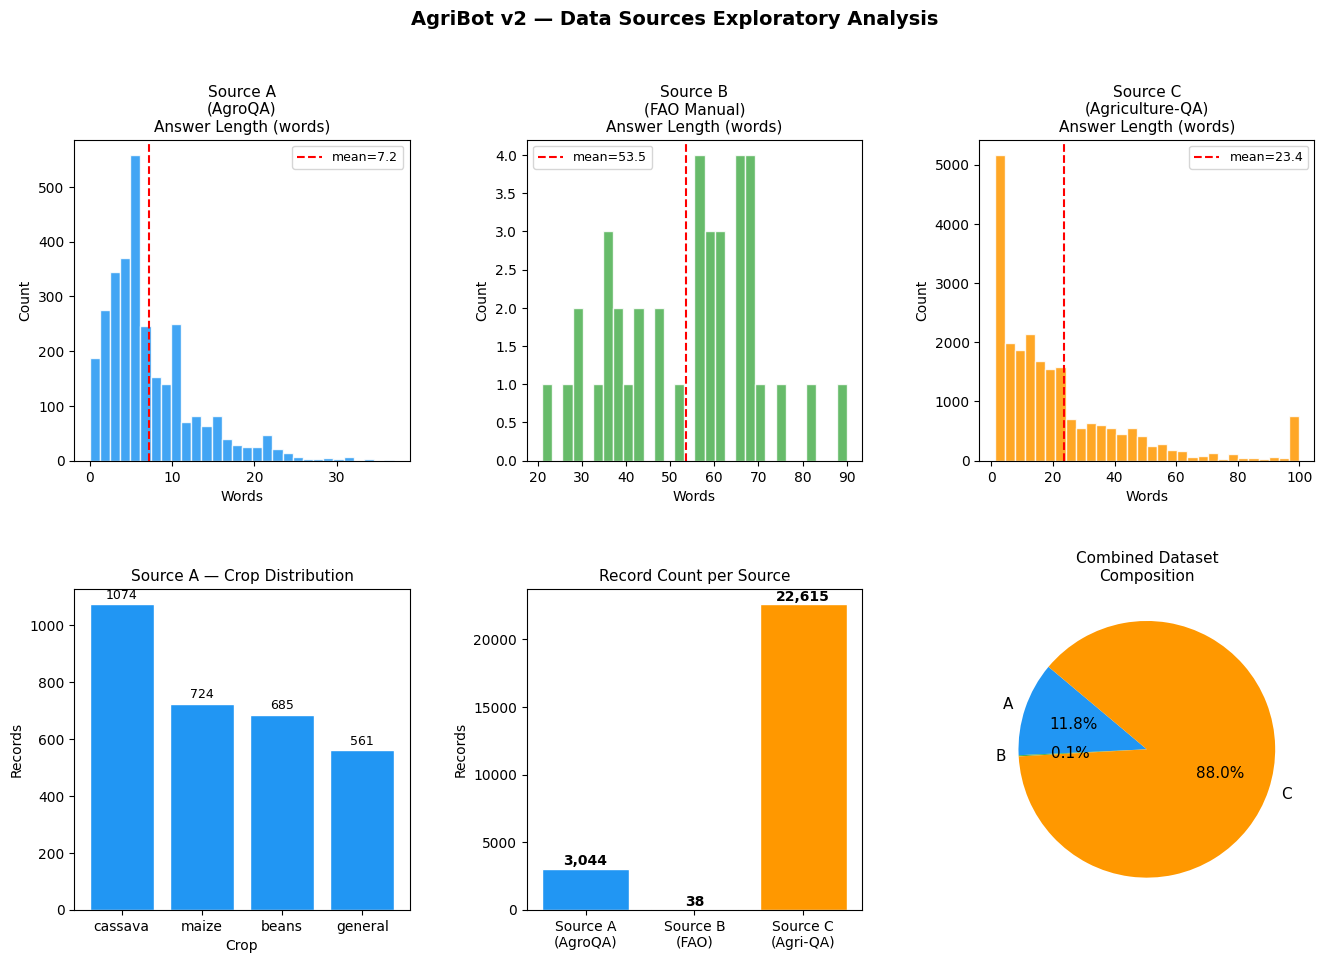

Total records across all sources: 25,697


In [ ]:
# ── Comparative EDA Visualisation ───────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

palette = ['#2196F3', '#4CAF50', '#FF9800']

# Row 1: Answer length distributions
for i, (df_src, label) in enumerate([
        (df_A, 'Source A\n(AgroQA)'),
        (df_B, 'Source B\n(FAO Manual)'),
        (df_C, 'Source C\n(Agriculture-QA)')
]):
    ax = fig.add_subplot(gs[0, i])
    ax.hist(df_src['a_len'].clip(upper=100), bins=30, color=palette[i], edgecolor='white', alpha=0.85)
    ax.set_title(f'{label}\nAnswer Length (words)', fontsize=11)
    ax.set_xlabel('Words'); ax.set_ylabel('Count')
    mean_val = df_src['a_len'].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'mean={mean_val:.1f}')
    ax.legend(fontsize=9)

# Row 2: Crop distribution (A only), record counts, combined summary
ax_crop = fig.add_subplot(gs[1, 0])
crop_counts = df_A['Crop'].value_counts()
ax_crop.bar(crop_counts.index, crop_counts.values, color=palette[0], edgecolor='white')
ax_crop.set_title('Source A — Crop Distribution', fontsize=11)
ax_crop.set_xlabel('Crop'); ax_crop.set_ylabel('Records')
for rect, val in zip(ax_crop.patches, crop_counts.values):
    ax_crop.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 10,
                 str(val), ha='center', va='bottom', fontsize=9)

ax_cnt = fig.add_subplot(gs[1, 1])
labels  = ['Source A\n(AgroQA)', 'Source B\n(FAO)', 'Source C\n(Agri-QA)']
sizes   = [len(df_A), len(df_B), len(df_C)]
bars    = ax_cnt.bar(labels, sizes, color=palette, edgecolor='white')
ax_cnt.set_title('Record Count per Source', fontsize=11)
ax_cnt.set_ylabel('Records')
for bar, val in zip(bars, sizes):
    ax_cnt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax_pie = fig.add_subplot(gs[1, 2])
ax_pie.pie(sizes, labels=['A', 'B', 'C'], colors=palette, autopct='%1.1f%%',
           startangle=140, textprops={'fontsize': 11})
ax_pie.set_title('Combined Dataset\nComposition', fontsize=11)

fig.suptitle('AgriBot v2 — Data Sources Exploratory Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('eda_sources.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Total records across all sources: {sum(sizes):,}")

---
## Section 2 — Data Augmentation & Preprocessing

### On the `Crop` Column

**Should we keep the `Crop` category?**

Short answer: **Yes, but as optional metadata** — normalised to `'general'` when absent.

- **Source A** carries explicit crop labels (`cassava`, `maize`, `beans`, `general`) and is the only source with fine-grained crop context. Discarding this would lose specificity in fine-tuned prompts.
- **Sources B & C** have no crop column — adding `'general'` as a default lets us unify the schema without fabricating information.
- In the RAG layer, crop context is recovered through semantic retrieval rather than explicit label matching, so the label matters less at inference time.

### Preprocessing Steps

1. Normalise column names across all three sources → `crop`, `question`, `answer`
2. Strip leading/trailing whitespace; collapse internal whitespace
3. Remove non-printable characters and excessive punctuation
4. Drop rows with empty or null `question` / `answer`
5. Filter by minimum answer length (≥ 3 words) to remove noise
6. Truncate very long answers to `MAX_TARGET_LEN` tokens worth of words
7. Exact-duplicate removal (on `question` + `answer`)
8. Tag each row with its `source` label for traceability

In [ ]:
# ── Text cleaning utilities ─────────────────────────────────────────────────

def clean_text(text: str) -> str:
    """Normalise a single text string."""
    text = str(text).strip()
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', text)   # remove control chars
    text = re.sub(r'\s+', ' ', text)                      # collapse whitespace
    text = text.strip()
    return text


def normalize_source(
    df: pd.DataFrame,
    source_name: str,
    question_col: str,
    answer_col: str,
    crop_col: str = None,
) -> pd.DataFrame:
    """
    Normalise any source dataframe into the unified schema:
        crop | question | answer | source
    """
    out = pd.DataFrame()
    out['question'] = df[question_col].apply(clean_text)
    out['answer']   = df[answer_col].apply(clean_text)

    if crop_col and crop_col in df.columns:
        out['crop'] = (
            df[crop_col]
            .astype(str)
            .str.lower()
            .str.strip()
            .fillna('general')
            .replace({'nan': 'general', '': 'general'})
        )
    else:
        out['crop'] = 'general'

    out['source'] = source_name
    return out


def quality_filter(df: pd.DataFrame, min_answer_words: int = 3) -> pd.DataFrame:
    """Drop low-quality and null rows."""
    df = df.dropna(subset=['question', 'answer'])
    df = df[df['question'].str.strip() != '']
    df = df[df['answer'].str.strip() != '']
    # Minimum answer length
    df = df[df['answer'].str.split().str.len() >= min_answer_words]
    return df


print("Preprocessing functions defined.")

Preprocessing functions defined.


In [ ]:
# ── Detect column names for Source C (may vary) ─────────────────────────────
q_col_C = [c for c in df_C.columns if 'question' in c.lower()][0]
a_col_C = [c for c in df_C.columns if 'answer'   in c.lower()][0]
print(f"Source C columns → question: '{q_col_C}', answer: '{a_col_C}'")

# ── Normalise each source ────────────────────────────────────────────────────
norm_A = normalize_source(df_A, source_name='agroqa',
                          question_col='Question', answer_col='Answer',
                          crop_col='Crop')

norm_B = normalize_source(df_B, source_name='fao_manual',
                          question_col='Question', answer_col='Answer',
                          crop_col='Crop')

norm_C = normalize_source(df_C, source_name='agri_qa',
                          question_col=q_col_C, answer_col=a_col_C)

print(f"\nNormalised shapes:")
print(f"  A: {norm_A.shape}")
print(f"  B: {norm_B.shape}")
print(f"  C: {norm_C.shape}")

norm_A.head(2)

Source C columns → question: 'question', answer: 'answers'

Normalised shapes:
  A: (3044, 4)
  B: (38, 4)
  C: (22615, 4)


,question,answer,crop,source
0,"Apart from hand weeding, what other method use...",Machinery weeders are available,maize,agroqa
1,"Apart from insecticide, what other method used...",Use resistant verities and increase on water a...,beans,agroqa


In [ ]:
# ── Merge all three sources ──────────────────────────────────────────────────
df_combined = pd.concat([norm_A, norm_B, norm_C], ignore_index=True)
print(f"After merge        : {len(df_combined):,} rows")

# ── Quality filter ───────────────────────────────────────────────────────────
df_combined = quality_filter(df_combined, min_answer_words=3)
print(f"After quality filter: {len(df_combined):,} rows")

# ── Deduplication ────────────────────────────────────────────────────────────
before_dedup = len(df_combined)
df_combined  = df_combined.drop_duplicates(subset=['question', 'answer'])
df_combined  = df_combined.reset_index(drop=True)
print(f"After deduplication : {len(df_combined):,} rows  (removed {before_dedup - len(df_combined):,} duplicates)")

# ── Source distribution after cleaning ──────────────────────────────────────
print(f"\nSource breakdown:")
print(df_combined['source'].value_counts().to_string())
print(f"\nCrop breakdown (top 10):")
print(df_combined['crop'].value_counts().head(10).to_string())

After merge        : 25,697 rows
After quality filter: 22,149 rows
After deduplication : 4,774 rows  (removed 17,375 duplicates)

Source breakdown:
source
agroqa        2580
agri_qa       2156
fao_manual      38

Crop breakdown (top 10):
crop
general    2669
cassava     908
beans       602
maize       595


COMBINED DATASET SUMMARY
Total records    : 4,774
Unique questions : 4,644

Question length (words)
count    4774.0
mean        8.9
std         3.3
min         2.0
25%         7.0
50%         9.0
75%        10.8
max        41.0

Answer length (words)
count    4774.0
mean       19.5
std        22.6
min         3.0
25%         6.0
50%        11.0
75%        25.0
max       348.0


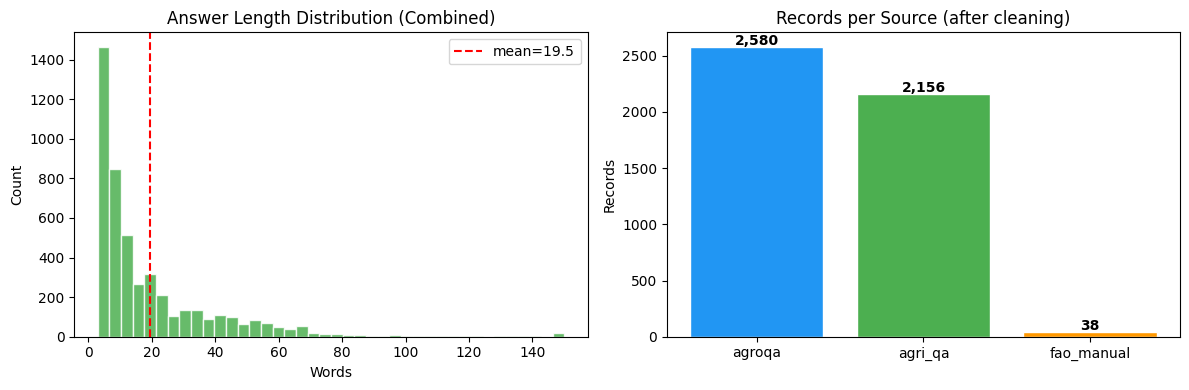

In [ ]:
# ── Final dataset statistics ─────────────────────────────────────────────────
df_combined['q_words'] = df_combined['question'].str.split().str.len()
df_combined['a_words'] = df_combined['answer'].str.split().str.len()

print("COMBINED DATASET SUMMARY")
print("=" * 45)
print(f"Total records    : {len(df_combined):,}")
print(f"Unique questions : {df_combined['question'].nunique():,}")
print(f"\nQuestion length (words)")
print(df_combined['q_words'].describe().round(1).to_string())
print(f"\nAnswer length (words)")
print(df_combined['a_words'].describe().round(1).to_string())

# Visualise answer length distribution post-merge
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_combined['a_words'].clip(upper=150), bins=40, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].set_title('Answer Length Distribution (Combined)', fontsize=12)
axes[0].set_xlabel('Words'); axes[0].set_ylabel('Count')
axes[0].axvline(df_combined['a_words'].mean(), color='red', linestyle='--',
                label=f"mean={df_combined['a_words'].mean():.1f}")
axes[0].legend()

src_counts = df_combined['source'].value_counts()
axes[1].bar(src_counts.index, src_counts.values,
            color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='white')
axes[1].set_title('Records per Source (after cleaning)', fontsize=12)
axes[1].set_ylabel('Records')
for bar, val in zip(axes[1].patches, src_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('combined_dataset_stats.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Tokenisation

**Model:** `google/flan-t5-base` (250M parameters — 3× larger than v1's small)

**Prompt format:**
```
# Crop-specific row
"answer farming question about cassava: What is the best spacing for cassava?"

# General row
"answer farming question: Why is crop rotation important?"
```

The instruction prefix conditions the encoder on the task; adding crop context when available gives the decoder a richer signal.

**Label padding:** pad tokens are replaced with `-100` so they are ignored in the cross-entropy loss.

In [ ]:
# ── Load FLAN-T5-base tokeniser ──────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f"Tokeniser loaded  : {BASE_MODEL}")
print(f"Vocab size        : {tokenizer.vocab_size:,}")
print(f"Model max length  : {tokenizer.model_max_length}")

Tokeniser loaded  : google/flan-t5-base
Vocab size        : 32,100
Model max length  : 512


In [ ]:
# ── Build task-specific instruction prompts ──────────────────────────────────

GENERAL_CROPS = {'general', 'nan', '', 'none'}

def format_prompt(row: pd.Series) -> str:
    """Construct the instruction prefix + question string."""
    crop = str(row['crop']).lower().strip()
    if crop not in GENERAL_CROPS:
        return f"answer farming question about {crop}: {row['question']}"
    return f"answer farming question: {row['question']}"


df_combined['input_text'] = df_combined.apply(format_prompt, axis=1)

# Sanity check
print("Sample prompts:")
for _, row in df_combined[df_combined['crop'] != 'general'].head(3).iterrows():
    print(f"  IN : {row['input_text']}")
    print(f"  OUT: {row['answer']}")
    print()
for _, row in df_combined[df_combined['crop'] == 'general'].head(2).iterrows():
    print(f"  IN : {row['input_text']}")
    print(f"  OUT: {row['answer']}")
    print()

Sample prompts:
  IN : answer farming question about maize: Apart from hand weeding, what other method used to weed maize
  OUT: Machinery weeders are available

  IN : answer farming question about beans: Apart from insecticide, what other method used to control bean weevils?
  OUT: Use resistant verities and increase on water availability for crop vigor

  IN : answer farming question about maize: Apart from sun drying which other method used for drying maize
  OUT: Use tarpaulins or cemented floor free from dust

  IN : answer farming question: As a farmer which method is good to prevent soil erosion
  OUT: Farmers can terrace their gardens or mulch their gardens to stop erosion

  IN : answer farming question: As a farmer, How can I control pest
  OUT: Spray some pests and if possible use resistant varieties



In [ ]:
# ── Train / Validation / Test split  (70 / 15 / 15) ─────────────────────────
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(df_combined, test_size=0.30, random_state=SEED)
df_val,   df_test = train_test_split(df_temp,     test_size=0.50, random_state=SEED)

print(f"Train : {len(df_train):,}  ({len(df_train)/len(df_combined):.1%})")
print(f"Val   : {len(df_val):,}  ({len(df_val)/len(df_combined):.1%})")
print(f"Test  : {len(df_test):,}  ({len(df_test)/len(df_combined):.1%})")

# Verify no source leakage from dedup
print(f"\nSource distribution (train):")
print(df_train['source'].value_counts().to_string())

Train : 3,341  (70.0%)
Val   : 716  (15.0%)
Test  : 717  (15.0%)

Source distribution (train):
source
agroqa        1793
agri_qa       1523
fao_manual      25


In [ ]:
# ── Convert to HuggingFace Dataset ───────────────────────────────────────────
cols = ['input_text', 'answer']

hf_train = Dataset.from_pandas(df_train[cols].reset_index(drop=True))
hf_val   = Dataset.from_pandas(df_val[cols].reset_index(drop=True))
hf_test  = Dataset.from_pandas(df_test[cols].reset_index(drop=True))

dataset = DatasetDict({'train': hf_train, 'validation': hf_val, 'test': hf_test})
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['input_text', 'answer'],
        num_rows: 3341
    })
    validation: Dataset({
        features: ['input_text', 'answer'],
        num_rows: 716
    })
    test: Dataset({
        features: ['input_text', 'answer'],
        num_rows: 717
    })
})


In [ ]:
# ── Tokenise ─────────────────────────────────────────────────────────────────

def tokenize_batch(examples):
    """
    Tokenise WITHOUT pre-padding.

    Do NOT use padding='max_length' here and do NOT manually replace pad
    tokens with -100.  When you pre-pad and then pass to DataCollatorForSeq2Seq,
    its internal _shift_right() builds decoder_input_ids from those labels —
    most positions are already -100, so _shift_right fills them with pad_token_id=0,
    giving the decoder an all-padding input → no real signal → loss = 0 and stuck.

    Letting DataCollatorForSeq2Seq own ALL padding means it:
      • pads each batch to its longest sequence (memory-efficient)
      • replaces label padding with -100 via label_pad_token_id
      • correctly builds decoder_input_ids from the real token sequences
    """
    model_inputs = tokenizer(
        examples['input_text'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples['answer'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs


tokenized = dataset.map(
    tokenize_batch,
    batched=True,
    batch_size=512,
    remove_columns=['input_text', 'answer'],
    desc='Tokenising'
)

print(tokenized)
print(f"\nSample (train[0]):")
print(f"  input len : {len(tokenized['train'][0]['input_ids'])} tokens (unpadded)")
print(f"  label len : {len(tokenized['train'][0]['labels'])} tokens (unpadded)")


---
## Section 4 — Fine-Tuning with HuggingFace Trainer

**Why FLAN-T5-base?**
- 3× more parameters than v1's small (250M vs 77M)
- FLAN instruction-tuning means it already understands task-prefix prompts
- Fits comfortably in 15.6 GB VRAM with `fp16=True` and batch size 16

**Key training decisions:**
- Reduced epochs (5 vs 10) because the dataset is 8× larger — each epoch covers far more data
- Warmup ratio 5% of total steps for stable initial learning
- `load_best_model_at_end=True` with `metric_for_best_model='rouge1'` to restore the best checkpoint

In [ ]:
# ── Load FLAN-T5-base ────────────────────────────────────────────────────────
model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Total parameters     : 247,577,856
Trainable parameters : 247,577,856


In [ ]:
# ── Evaluation metrics (ROUGE + BLEU) ───────────────────────────────────────
rouge_metric = evaluate.load('rouge')
bleu_metric  = evaluate.load('sacrebleu')

# def compute_metrics(eval_preds):
#     preds, labels = eval_preds

#     # Decode predictions (handle numpy int arrays)
#     decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

#     # Replace -100 padding tokens with pad_token_id before decoding labels
#     labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
#     decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

#     # Strip whitespace
#     decoded_preds  = [p.strip() for p in decoded_preds]
#     decoded_labels = [l.strip() for l in decoded_labels]

#     # ROUGE
#     rouge_result = rouge_metric.compute(
#         predictions=decoded_preds,
#         references=decoded_labels,
#         use_stemmer=True,
#     )
#     result = {k: round(v, 4) for k, v in rouge_result.items()}

#     # BLEU (SacreBLEU expects list-of-lists for references)
#     bleu_result = bleu_metric.compute(
#         predictions=decoded_preds,
#         references=[[l] for l in decoded_labels],
#     )
#     result['bleu'] = round(bleu_result['score'] / 100, 4)

#     return result

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Fix 1: unpack tuple (logits, past_key_values, ...)
    if isinstance(preds, tuple):
        preds = preds[0]

    # Fix 2: convert logits → token ids if 3D
    if preds.ndim == 3:
        preds = np.argmax(preds, axis=-1)

    # Fix 3: clamp to valid vocab range
    preds = np.clip(preds, 0, tokenizer.vocab_size - 1).astype(np.int32)

    # Decode predictions
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Replace -100 padding tokens with pad_token_id before decoding labels
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Strip whitespace
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    # ROUGE
    rouge_result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    result = {k: round(v, 4) for k, v in rouge_result.items()}

    # BLEU (SacreBLEU expects list-of-lists for references)
    bleu_result = bleu_metric.compute(
        predictions=decoded_preds,
        references=[[l] for l in decoded_labels],
    )
    result['bleu'] = round(bleu_result['score'] / 100, 4)

    return result


print("compute_metrics function defined.")

compute_metrics function defined.


In [ ]:
# ── Training arguments ───────────────────────────────────────────────────────

# warmup_ratio is deprecated in Trainer v5 — compute steps explicitly
_steps_per_epoch = len(tokenized['train']) // BATCH_SIZE
_total_steps     = _steps_per_epoch * TRAIN_EPOCHS
WARMUP_STEPS     = max(1, int(WARMUP_RATIO * _total_steps))
print(f"Steps / epoch : {_steps_per_epoch}")
print(f"Total steps   : {_total_steps}")
print(f"Warmup steps  : {WARMUP_STEPS}  ({WARMUP_RATIO:.0%} of total)")

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training schedule
    num_train_epochs=TRAIN_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=WARMUP_STEPS,
    max_grad_norm=MAX_GRAD_NORM,

    # Evaluation & checkpointing
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='rouge1',
    greater_is_better=True,
    save_total_limit=2,

    # Generation settings for eval
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,

    # fp16=False — FLAN-T5-base attention activations overflow fp16 on T4
    # (Turing arch, no bfloat16).  The forward pass itself produces NaN before
    # gradients are even computed, so max_grad_norm cannot help.
    # With ~3K training samples the extra wall-clock time is only ~3-4 minutes.
    fp16=False,

    dataloader_num_workers=2,
    logging_steps=max(1, _steps_per_epoch // 4),  # ~4 logs per epoch
    report_to='none',
    seed=SEED,
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

print("\nTraining arguments set.")
print("  fp16        : False  (disabled — prevents forward-pass NaN on T4)")
print(f"  lr          : {LEARNING_RATE}")
print(f"  grad clip   : {MAX_GRAD_NORM}")


In [ ]:
# ── Initialise Seq2SeqTrainer ────────────────────────────────────────────────
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer initialised.")
print(f"  Train batches / epoch : {len(tokenized['train']) // BATCH_SIZE:,}")
print(f"  Total training steps  : {(len(tokenized['train']) // BATCH_SIZE) * TRAIN_EPOCHS:,}")

Trainer initialised.
  Train batches / epoch : 208
  Total training steps  : 1,040


In [ ]:
# ── Train ────────────────────────────────────────────────────────────────────
print("Starting fine-tuning …")
train_result = trainer.train()

print("\nTraining complete.")
print(f"  Total train runtime : {train_result.metrics['train_runtime']:.0f} s")
print(f"  Train loss (final)  : {train_result.metrics['train_loss']:.4f}")

Starting fine-tuning …


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Bleu
1,0.000000,nan,0.061400,0.006700,0.057500,0.057700,0.000200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokeniser saved to: /content/drive/MyDrive/1_UM/1_NLP Project/flan-t5-agribot-v2


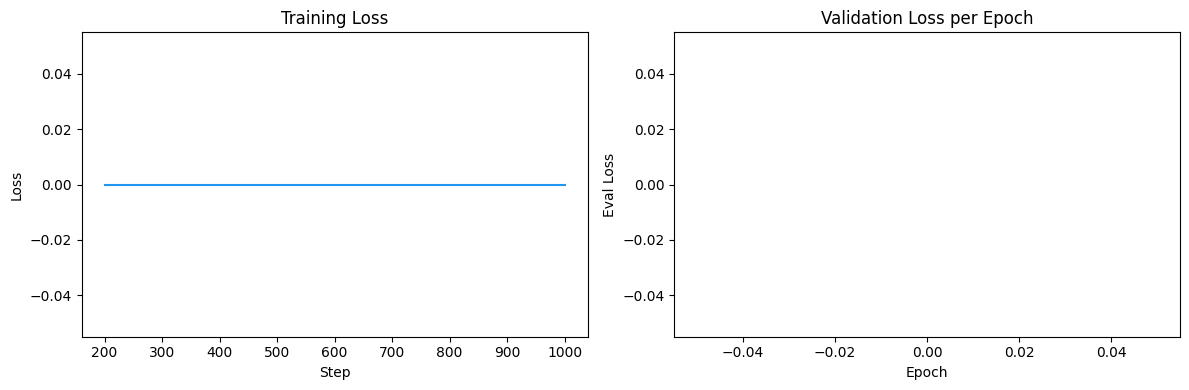

In [ ]:
# ── Save best model & tokeniser ──────────────────────────────────────────────
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model and tokeniser saved to: {OUTPUT_DIR}")

# Plot training loss if available
if hasattr(trainer.state, 'log_history') and trainer.state.log_history:
    train_logs = [l for l in trainer.state.log_history if 'loss' in l and 'eval_loss' not in l]
    eval_logs  = [l for l in trainer.state.log_history if 'eval_loss' in l]

    if train_logs and eval_logs:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot([l['step'] for l in train_logs], [l['loss'] for l in train_logs],
                     color='#2196F3', linewidth=1.5)
        axes[0].set_title('Training Loss', fontsize=12)
        axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')

        axes[1].plot([l['epoch'] for l in eval_logs], [l['eval_loss'] for l in eval_logs],
                     color='#FF5722', marker='o', linewidth=1.5)
        axes[1].set_title('Validation Loss per Epoch', fontsize=12)
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Eval Loss')

        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
        plt.show()

---
## Section 5 — RAG Pipeline (Retrieval-Augmented Generation)

**Why RAG?**  
Fine-tuned weights encode general patterns, but the model can hallucinate or give stale advice on niche queries. RAG anchors every answer to documents actually in the knowledge base.

**Architecture:**
```
User question
    │
    ▼
[Embedding]  all-MiniLM-L6-v2  →  query vector
    │
    ▼
[Retrieval]  FAISS IndexFlatIP  →  top-k chunks (cosine similarity)
    │
    ▼
[Prompt]   build_rag_prompt()  →  Context + Question string
    │
    ▼
[Generate]  FLAN-T5-base (fine-tuned)  →  final answer
```

**Knowledge base:** every `question + answer` pair from the training split, embedded with `all-MiniLM-L6-v2` and stored in a FAISS flat index (inner-product after L2 normalisation = cosine similarity).

In [ ]:
# ── Load sentence-transformer embedding model ────────────────────────────────
embed_model = SentenceTransformer(EMBED_MODEL, device=device)
print(f"Embedding model loaded : {EMBED_MODEL}")
print(f"Embedding dimension    : {embed_model.get_sentence_embedding_dimension()}")

In [ ]:
# ── Build the knowledge base (from training data) ────────────────────────────

def build_knowledge_base(
    df: pd.DataFrame,
    embed_model: SentenceTransformer,
    index_path: str,
    docs_path: str,
    batch_size: int = 512,
):
    """
    Embed all QA pairs and store in a FAISS flat-IP index.
    Documents: list of dicts with keys text, question, answer, crop, source.
    Saves index and docs to disk so they can be reloaded without re-embedding.
    Returns (faiss_index, docs).
    """
    docs = [
        {
            'text'    : f"Q: {row['question']} A: {row['answer']}",
            'question': row['question'],
            'answer'  : row['answer'],
            'crop'    : row['crop'],
            'source'  : row['source'],
        }
        for _, row in df.iterrows()
    ]

    texts = [d['text'] for d in docs]
    print(f"Embedding {len(texts):,} documents …")

    embeddings = embed_model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,   # L2-normalise → cosine via IP
        convert_to_numpy=True,
    ).astype('float32')

    dim   = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    # Persist to disk
    os.makedirs(os.path.dirname(index_path) or '.', exist_ok=True)
    faiss.write_index(index, index_path)
    with open(docs_path, 'wb') as f:
        pickle.dump(docs, f)

    print(f"FAISS index saved  : {index_path}")
    print(f"Docs list saved    : {docs_path}")
    print(f"Index size         : {index.ntotal:,} vectors  (dim={dim})")
    return index, docs


# Build from training split only — no test-set leakage
faiss_index, kb_docs = build_knowledge_base(
    df_train,
    embed_model,
    index_path=INDEX_PATH,
    docs_path=DOCS_PATH,
)

In [ ]:
# ── Helper: reload KB from disk (use after kernel restart) ──────────────────
def load_knowledge_base(index_path: str, docs_path: str):
    index = faiss.read_index(index_path)
    with open(docs_path, 'rb') as f:
        docs = pickle.load(f)
    print(f"Loaded FAISS index  : {index.ntotal:,} vectors")
    print(f"Loaded docs         : {len(docs):,} records")
    return index, docs

# Uncomment to reload without re-embedding:
# faiss_index, kb_docs = load_knowledge_base(INDEX_PATH, DOCS_PATH)

In [ ]:
# ── Retrieval function ───────────────────────────────────────────────────────

def retrieve(
    question: str,
    faiss_index,
    docs: list,
    embed_model: SentenceTransformer,
    top_k: int = 3,
    threshold: float = 0.30,
) -> list:
    """
    Retrieve the top-k most similar documents above the cosine similarity threshold.
    Returns an empty list if no chunk meets the threshold (triggers guardrail layer 2).
    """
    query_emb = embed_model.encode(
        [question],
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype('float32')

    scores, indices = faiss_index.search(query_emb, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0 and float(score) >= threshold:
            results.append({**docs[idx], 'score': float(score)})

    return results


# Quick sanity check
test_q   = "How do I control pests on cassava?"
test_res = retrieve(test_q, faiss_index, kb_docs, embed_model)
print(f"Query: {test_q!r}")
for i, r in enumerate(test_res, 1):
    print(f"  [{i}] score={r['score']:.3f} | {r['text'][:90]} …")

In [ ]:
# ── Prompt builder ───────────────────────────────────────────────────────────

def build_rag_prompt(question: str, chunks: list) -> str:
    """
    Assemble the RAG prompt by injecting retrieved context before the question.
    The instruction prefix tells FLAN-T5 how to use the context.
    """
    context_lines = [
        f"[{i+1}] Q: {c['question']} A: {c['answer']}"
        for i, c in enumerate(chunks)
    ]
    context = "\n".join(context_lines)
    return (
        f"answer farming question using context:\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}"
    )


# ── Answer generator ─────────────────────────────────────────────────────────

def generate_answer(prompt: str, model, tokenizer, max_new_tokens: int = 128) -> str:
    """Run the fine-tuned FLAN-T5-base on the prompt."""
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        max_length=MAX_RAG_INPUT,
        truncation=True,
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            no_repeat_ngram_size=2,
            early_stopping=True,
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()


print("RAG components (build_rag_prompt, generate_answer) defined.")

---
## Section 6 — Guardrails

Two independent safety layers wrap the RAG pipeline:

```
User question
      │
      ▼
┌─────────────────────────────────────────┐
│  LAYER 1 — Intent guardrail             │
│  is_farming_related(question)           │
│  Keyword overlap against agriculture    │
│  vocabulary.  If fails → polite refusal │
└─────────────────────────────────────────┘
      │  (passes)
      ▼
   retrieve(question, top_k=3, threshold=0.30)
      │
┌─────────────────────────────────────────┐
│  LAYER 2 — Retrieval confidence guard  │
│  If no chunk passes threshold →        │
│  "not in my knowledge base" response   │
└─────────────────────────────────────────┘
      │  (passes)
      ▼
   build_rag_prompt() → generate_answer()
      │
      ▼
   Final answer
```

In [ ]:
# ── Layer 1: Intent / domain guardrail ───────────────────────────────────────

FARMING_KEYWORDS = {
    # Crops
    'crop', 'crops', 'cassava', 'maize', 'corn', 'beans', 'rice', 'wheat',
    'sorghum', 'millet', 'soybean', 'groundnut', 'peanut', 'potato', 'tomato',
    'vegetable', 'vegetables', 'fruit', 'fruits', 'orchard', 'cocoa', 'coffee',
    # Soil & inputs
    'soil', 'fertilizer', 'fertiliser', 'compost', 'manure', 'nitrogen',
    'phosphorus', 'potassium', 'pH', 'mulch', 'organic', 'amendment',
    # Pest & disease
    'pest', 'pests', 'disease', 'fungus', 'blight', 'aphid', 'worm', 'weevil',
    'pesticide', 'herbicide', 'fungicide', 'insecticide', 'spray', 'resistant',
    # Practices
    'farm', 'farming', 'agriculture', 'agronomy', 'plant', 'planting', 'seed',
    'seeds', 'germinate', 'germination', 'harvest', 'harvesting', 'weed',
    'weeding', 'irrigate', 'irrigation', 'water', 'drainage', 'spacing',
    'pruning', 'thinning', 'transplant', 'nursery', 'seedling', 'rotation',
    'intercrop', 'agroforestry', 'greenhouse', 'yield', 'produce',
    # Livestock
    'livestock', 'cattle', 'cow', 'poultry', 'chicken', 'goat', 'pig',
    # Land
    'field', 'plot', 'acre', 'hectare', 'land', 'ridge', 'furrow',
    # Context
    'farmer', 'farmer\'s', 'grow', 'growing', 'extension', 'season',
    'rainfall', 'drought', 'climate', 'weather',
}


def is_farming_related(question: str, min_matches: int = 1) -> bool:
    """
    Layer 1 guardrail: check whether the question overlaps with the
    agricultural vocabulary.  A single keyword match is sufficient.
    """
    tokens = set(re.sub(r"[^\w\s]", "", question.lower()).split())
    return len(tokens & FARMING_KEYWORDS) >= min_matches


# Smoke test
test_cases = [
    ("How do I control aphids on my maize?", True),
    ("What is the capital of France?",       False),
    ("When should I harvest cassava?",        True),
    ("How do I write a Python script?",       False),
    ("Best fertilizer for tomato plants?",    True),
]
print("Intent guardrail smoke test:")
for q, expected in test_cases:
    result = is_farming_related(q)
    status = '✓' if result == expected else '✗'
    print(f"  {status}  {result!s:5}  | {q}")

In [ ]:
# # ── Main AgriBot RAG pipeline ────────────────────────────────────────────────

# def agribot_rag(
#     question: str,
#     model,
#     tokenizer,
#     faiss_index,
#     docs: list,
#     embed_model: SentenceTransformer,
#     top_k: int = 3,
#     threshold: float = 0.30,
#     verbose: bool = False,
# ) -> str:
#     """
#     Full RAG pipeline with two guardrail layers.

#     Layer 1 — Intent: reject non-farming questions immediately.
#     Layer 2 — Confidence: if no chunk is similar enough, decline gracefully.
#     """

#     # ── Layer 1: Domain intent check ─────────────────────────────────────────
#     if not is_farming_related(question):
#         return (
#             "I'm AgriBot! I specialise in farming and agriculture. "
#             "Please ask me about crops, soil, pest management, "
#             "irrigation, or other agricultural topics."
#         )

#     # ── Retrieval ────────────────────────────────────────────────────────────
#     chunks = retrieve(question, faiss_index, docs, embed_model, top_k=top_k, threshold=threshold)

#     if verbose:
#         print(f"Retrieved {len(chunks)} chunk(s):")
#         for c in chunks:
#             print(f"  score={c['score']:.3f}  source={c['source']}  | {c['text'][:80]} …")
#         print()

#     # ── Layer 2: Retrieval confidence check ──────────────────────────────────
#     if not chunks:
#         return (
#             "I don't have enough information about that in my knowledge base. "
#             "Try asking with more specific agricultural terms (e.g. crop name, "
#             "pest type, or farming practice)."
#         )

#     # ── Generate answer ──────────────────────────────────────────────────────
#     prompt = build_rag_prompt(question, chunks)
#     return generate_answer(prompt, model, tokenizer)


# print("agribot_rag() defined.")


import re

def is_valid_response(text: str, min_real_words: int = 3) -> bool:
    """
    Reject responses that are mostly gibberish.
    A 'real word' here means >= 3 chars and only standard characters.
    """
    words = text.split()
    real_words = [w for w in words if re.match(r'^[a-zA-Z]{3,}$', w)]
    return len(real_words) >= min_real_words

def agribot_rag(question, model, tokenizer, faiss_index, docs, embed_model,
                top_k=3, threshold=0.30, verbose=False):

    if not is_farming_related(question):
        return "I'm AgriBot! I specialise in farming and agriculture. ..."

    chunks = retrieve(question, faiss_index, docs, embed_model, top_k=top_k, threshold=threshold)

    if not chunks:
        return "I don't have enough information about that in my knowledge base. ..."

    prompt = build_rag_prompt(question, chunks)
    answer = generate_answer(prompt, model, tokenizer)

    # ── Layer 3: Output sanity check ─────────────────────────────────────────
    if not is_valid_response(answer):
        # Fall back to the best retrieved chunk instead
        return f"Based on my knowledge base: {chunks[0]['text']}"

    return answer

In [ ]:
# ── End-to-end inference test ────────────────────────────────────────────────

test_questions = [
    # Within-domain
    "How do I control pests on cassava?",
    "What is the best spacing for maize planting?",
    "Why is crop rotation important?",
    "How often should I water beans during dry season?",
    # FAO-style
    "What is the objective of agricultural extension?",
    # Out-of-domain → should trigger Layer 1 guardrail
    "Who won the football world cup?",
    # Low-confidence within domain → may trigger Layer 2
    "What is the cure for alien plant viruses on exoplanets?",
]

model.eval()
print("=" * 70)
for q in test_questions:
    answer = agribot_rag(
        q, model, tokenizer, faiss_index, kb_docs, embed_model, verbose=False
    )
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("-" * 70)

---
## Section 7 — Evaluation

Three complementary metrics:

| Metric | Measures | Limitation |
|--------|----------|------------|
| ROUGE-1/2/L | N-gram overlap | Punishes valid paraphrases |
| BLEU | Precision of n-grams | Heavily penalises short outputs |
| BERTScore | Semantic similarity via contextual embeddings | Slower; less interpretable |

We also provide a **human evaluation template** (1–5 Likert scale) for qualitative assessment, and compare v1 vs v2 results.

In [ ]:
# ── Generate predictions on the test set ────────────────────────────────────
print("Running test-set evaluation …")

test_predictions = trainer.predict(
    tokenized['test'],
    metric_key_prefix='test',
)

pred_ids  = test_predictions.predictions
label_ids = test_predictions.label_ids

# trainer.predict() can return a tuple (generated_ids, decoder_hidden_states, …)
if isinstance(pred_ids, tuple):
    pred_ids = pred_ids[0]

# If logits were returned (3-D) convert to token ids via argmax
if pred_ids.ndim == 3:
    pred_ids = np.argmax(pred_ids, axis=-1)

# Cast to int32 — int64 with out-of-range values causes OverflowError in the
# SentencePiece tokenizer when it tries to convert to a C int internally
pred_ids  = np.clip(pred_ids,  0, tokenizer.vocab_size - 1).astype(np.int32)

# Replace -100 label padding with pad_token_id before decoding
label_ids_clean = np.where(label_ids != -100, label_ids, tokenizer.pad_token_id)
label_ids_clean = np.clip(label_ids_clean, 0, tokenizer.vocab_size - 1).astype(np.int32)

decoded_preds  = tokenizer.batch_decode(pred_ids,       skip_special_tokens=True)
decoded_labels = tokenizer.batch_decode(label_ids_clean, skip_special_tokens=True)

decoded_preds  = [p.strip() for p in decoded_preds]
decoded_labels = [l.strip() for l in decoded_labels]

print("\nSample predictions (test set):")
for i in range(min(5, len(decoded_preds))):
    print(f"  REF : {decoded_labels[i]}")
    print(f"  PRED: {decoded_preds[i]}")
    print()


In [ ]:
# ── ROUGE & BLEU ─────────────────────────────────────────────────────────────
rouge_result = rouge_metric.compute(
    predictions=decoded_preds,
    references=decoded_labels,
    use_stemmer=True,
)

bleu_result = bleu_metric.compute(
    predictions=decoded_preds,
    references=[[l] for l in decoded_labels],
)

print("TEST SET RESULTS — Fine-tuned FLAN-T5-base (v2)")
print("=" * 45)
for k, v in rouge_result.items():
    print(f"  {k:15}: {v:.4f}")
print(f"  {'BLEU':15}: {bleu_result['score']/100:.4f}")

In [ ]:
# ── BERTScore (semantic similarity) ─────────────────────────────────────────
from bert_score import score as bert_score_fn

# Evaluate on a subset for speed (full test set may take a few minutes)
EVAL_N = min(500, len(decoded_preds))

P, R, F1 = bert_score_fn(
    decoded_preds[:EVAL_N],
    decoded_labels[:EVAL_N],
    lang='en',
    verbose=True,
)

print(f"\nBERTScore (n={EVAL_N}):")
print(f"  Precision : {P.mean():.4f}")
print(f"  Recall    : {R.mean():.4f}")
print(f"  F1        : {F1.mean():.4f}")

In [ ]:
# ── v1 vs v2 Comparison ──────────────────────────────────────────────────────

# Version 1 results (from 1_poc_080426.ipynb)
v1_results = {
    'rouge1': 0.1722,
    'rouge2': 0.0481,
    'rougeL': 0.1671,
    'bleu'  : 0.0339,
}

v2_results = {
    'rouge1': rouge_result['rouge1'],
    'rouge2': rouge_result['rouge2'],
    'rougeL': rouge_result['rougeL'],
    'bleu'  : bleu_result['score'] / 100,
}

metrics_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
v1_vals = [v1_results['rouge1'], v1_results['rouge2'], v1_results['rougeL'], v1_results['bleu']]
v2_vals = [v2_results['rouge1'], v2_results['rouge2'], v2_results['rougeL'], v2_results['bleu']]

x   = range(len(metrics_labels))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

bars_v1 = ax.bar([i - w/2 for i in x], v1_vals, width=w, label='v1 (FLAN-T5-small, 3K)', color='#90CAF9', edgecolor='white')
bars_v2 = ax.bar([i + w/2 for i in x], v2_vals, width=w, label='v2 (FLAN-T5-base, ~25K + RAG)', color='#1565C0', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('AgriBot v1 vs v2 — Evaluation Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(v1_vals), max(v2_vals)) * 1.3)

for bar in bars_v1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for bar in bars_v2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('v1_vs_v2_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDelta (v2 - v1):")
for m, v1, v2 in zip(metrics_labels, v1_vals, v2_vals):
    delta = v2 - v1
    sign  = '+' if delta >= 0 else ''
    print(f"  {m:8}: {sign}{delta:+.4f}")

In [ ]:
# ── Human Evaluation Template ────────────────────────────────────────────────
# Use this to collect manual ratings (1–5 Likert) from domain experts.

HUMAN_EVAL_QUESTIONS = [
    "How do I prevent cassava mosaic disease?",
    "What fertilizer should I use for maize?",
    "When is the best time to plant beans?",
    "How do I improve soil fertility?",
    "What is the recommended spacing for cassava?",
]

RATING_CRITERIA = {
    'relevance'   : 'Does the answer address the question? (1=not at all, 5=completely)',
    'accuracy'    : 'Is the answer factually correct? (1=wrong, 5=fully correct)',
    'completeness': 'Is the answer sufficiently detailed? (1=very incomplete, 5=comprehensive)',
    'fluency'     : 'Is the answer grammatically natural? (1=very poor, 5=excellent)',
}

model.eval()
records = []
print("HUMAN EVALUATION TEMPLATE")
print("=" * 60)
print("Instructions: rate each answer 1–5 per criterion.\n")
for i, q in enumerate(HUMAN_EVAL_QUESTIONS, 1):
    answer = agribot_rag(q, model, tokenizer, faiss_index, kb_docs, embed_model)
    print(f"[{i}] Q: {q}")
    print(f"     A: {answer}")
    print(f"     Ratings: relevance=__ accuracy=__ completeness=__ fluency=__")
    print()
    records.append({'question': q, 'answer': answer,
                    'relevance': None, 'accuracy': None,
                    'completeness': None, 'fluency': None})

df_human_eval = pd.DataFrame(records)
# Save template for manual completion
df_human_eval.to_csv('human_eval_template.csv', index=False)
print("Human eval template saved → human_eval_template.csv")

---
## Section 8 — Deployment

The cell below writes a self-contained **Streamlit app** (`app.py`) that:
- Loads the fine-tuned model and FAISS index from disk
- Exposes a chat-style interface
- Applies both guardrail layers before generating answers

**To run locally:**
```bash
# 1. Copy model + index files next to app.py
# 2. Install dependencies
pip install streamlit transformers sentence-transformers faiss-cpu

# 3. Launch
streamlit run app.py
```

**To deploy on Streamlit Community Cloud:**
1. Push `app.py`, `requirements.txt`, and model artefacts to a GitHub repo
2. Connect the repo at https://share.streamlit.io

In [ ]:
%%writefile app.py
"""
AgriBot v2 — Streamlit UI
Run: streamlit run app.py
"""

import os
import re
import pickle
import numpy as np
import streamlit as st
import torch
import faiss
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer

# ── Config (update paths as needed) ─────────────────────────────────────────
MODEL_DIR   = os.getenv('MODEL_DIR',   './flan-t5-agribot-v2')
INDEX_PATH  = os.getenv('INDEX_PATH',  './agribot_faiss.index')
DOCS_PATH   = os.getenv('DOCS_PATH',   './agribot_docs.pkl')
EMBED_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
MAX_RAG_INPUT  = 512
MAX_NEW_TOKENS = 128
RETRIEVAL_TOP_K     = 3
RETRIEVAL_THRESHOLD = 0.30

FARMING_KEYWORDS = {
    'crop', 'crops', 'cassava', 'maize', 'corn', 'beans', 'rice', 'wheat',
    'sorghum', 'millet', 'soybean', 'groundnut', 'peanut', 'potato', 'tomato',
    'vegetable', 'vegetables', 'fruit', 'fruits', 'soil', 'fertilizer',
    'fertiliser', 'compost', 'manure', 'nitrogen', 'phosphorus', 'potassium',
    'pest', 'pests', 'disease', 'fungus', 'blight', 'aphid', 'pesticide',
    'herbicide', 'fungicide', 'insecticide', 'spray', 'farm', 'farming',
    'agriculture', 'agronomy', 'plant', 'planting', 'seed', 'seeds',
    'harvest', 'harvesting', 'weed', 'weeding', 'irrigate', 'irrigation',
    'spacing', 'pruning', 'rotation', 'intercrop', 'greenhouse', 'yield',
    'livestock', 'cattle', 'poultry', 'chicken', 'farmer', 'grow', 'growing',
    'extension', 'season', 'rainfall', 'drought',
}


# ── Model loading (cached) ──────────────────────────────────────────────────
@st.cache_resource(show_spinner='Loading AgriBot model …')
def load_model():
    device    = 'cuda' if torch.cuda.is_available() else 'cpu'
    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
    model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIR).to(device)
    model.eval()
    return tokenizer, model, device


@st.cache_resource(show_spinner='Loading knowledge base …')
def load_kb():
    embed_model = SentenceTransformer(EMBED_MODEL)
    index       = faiss.read_index(INDEX_PATH)
    with open(DOCS_PATH, 'rb') as f:
        docs = pickle.load(f)
    return embed_model, index, docs


# ── Guardrail helpers ───────────────────────────────────────────────────────
def is_farming_related(question: str) -> bool:
    tokens = set(re.sub(r'[^\w\s]', '', question.lower()).split())
    return bool(tokens & FARMING_KEYWORDS)


def retrieve(question, index, docs, embed_model, top_k=3, threshold=0.30):
    q_emb = embed_model.encode(
        [question], normalize_embeddings=True, convert_to_numpy=True
    ).astype('float32')
    scores, idxs = index.search(q_emb, top_k)
    return [
        {**docs[i], 'score': float(s)}
        for s, i in zip(scores[0], idxs[0])
        if i >= 0 and float(s) >= threshold
    ]


def build_rag_prompt(question, chunks):
    context = '\n'.join(
        f"[{i+1}] Q: {c['question']} A: {c['answer']}" for i, c in enumerate(chunks)
    )
    return (
        f"answer farming question using context:\n"
        f"Context:\n{context}\n\nQuestion: {question}"
    )


def generate(prompt, model, tokenizer, device):
    inputs = tokenizer(
        prompt, return_tensors='pt', max_length=MAX_RAG_INPUT, truncation=True
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS,
            num_beams=4, no_repeat_ngram_size=2, early_stopping=True,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()


def agribot_answer(question, tokenizer, model, device, embed_model, index, docs):
    if not is_farming_related(question):
        return (
            "I'm AgriBot! I specialise in farming and agriculture. "
            "Please ask me about crops, soil, pest management, or irrigation."
        ), []
    chunks = retrieve(question, index, docs, embed_model,
                      top_k=RETRIEVAL_TOP_K, threshold=RETRIEVAL_THRESHOLD)
    if not chunks:
        return (
            "I don't have enough information on that in my knowledge base. "
            "Try rephrasing with a specific crop or farming practice."
        ), []
    prompt = build_rag_prompt(question, chunks)
    return generate(prompt, model, tokenizer, device), chunks


# ── Streamlit UI ─────────────────────────────────────────────────────────────
st.set_page_config(page_title='AgriBot', page_icon='🌾', layout='centered')

st.title('🌾 AgriBot — Agricultural Chatbot')
st.caption(
    'Powered by FLAN-T5-base (fine-tuned) + RAG | '
    'University of Malaya · WQF7007 NLP · SDG 2 Zero Hunger'
)
st.divider()

tokenizer, model, device = load_model()
embed_model, faiss_index, kb_docs = load_kb()

if 'history' not in st.session_state:
    st.session_state.history = []

# Chat history
for msg in st.session_state.history:
    with st.chat_message(msg['role']):
        st.markdown(msg['content'])

# User input
if prompt := st.chat_input('Ask a farming question …'):
    st.session_state.history.append({'role': 'user', 'content': prompt})
    with st.chat_message('user'):
        st.markdown(prompt)

    with st.chat_message('assistant'):
        with st.spinner('Thinking …'):
            answer, chunks = agribot_answer(
                prompt, tokenizer, model, device, embed_model, faiss_index, kb_docs
            )
        st.markdown(answer)

        if chunks:
            with st.expander(f'Retrieved {len(chunks)} source(s)', expanded=False):
                for i, c in enumerate(chunks, 1):
                    st.markdown(
                        f"**[{i}]** *(score: {c['score']:.2f} | source: {c['source']})*  \n"
                        f"**Q:** {c['question']}  \n**A:** {c['answer']}"
                    )

    st.session_state.history.append({'role': 'assistant', 'content': answer})

# Sidebar — example questions
with st.sidebar:
    st.header('Example Questions')
    examples = [
        'How do I control pests on cassava?',
        'What is the best spacing for maize?',
        'Why is crop rotation important?',
        'What fertilizer should I use for beans?',
        'How do I improve soil fertility?',
    ]
    for ex in examples:
        if st.button(ex, use_container_width=True):
            st.session_state.history.append({'role': 'user', 'content': ex})
            answer, _ = agribot_answer(
                ex, tokenizer, model, device, embed_model, faiss_index, kb_docs
            )
            st.session_state.history.append({'role': 'assistant', 'content': answer})
            st.rerun()

    st.divider()
    if st.button('Clear chat', use_container_width=True):
        st.session_state.history = []
        st.rerun()

In [ ]:
%%writefile requirements.txt
streamlit>=1.32.0
transformers>=4.40.0
sentence-transformers>=2.7.0
faiss-cpu>=1.8.0
torch>=2.2.0
numpy>=1.26.0
pandas>=2.2.0

---
## Conclusion

### What was built

| Step | Component | Detail |
|------|-----------|--------|
| 1 | **Data augmentation** | 3 sources merged: AgroQA (crop-specific), FAO Manual (extension), Agriculture-QA (broad) |
| 2 | **Preprocessing** | Unified `crop/question/answer/source` schema, text cleaning, dedup, quality filter |
| 3 | **Tokenisation** | FLAN-T5-base with task-prefix prompts; -100 label masking |
| 4 | **Fine-tuning** | `Seq2SeqTrainer`, 5 epochs, ROUGE-best checkpoint |
| 5 | **RAG** | `all-MiniLM-L6-v2` embeddings + FAISS flat-IP index; top-3 retrieval |
| 6 | **Guardrails** | Layer 1: keyword intent check; Layer 2: retrieval confidence threshold |
| 7 | **Evaluation** | ROUGE, BLEU, BERTScore + human evaluation template |
| 8 | **Deployment** | Streamlit chat UI (`app.py`) with source citations |

### On the Crop column

The `crop` label from Source A is retained as **optional metadata**. For Sources B and C (no crop info) it defaults to `'general'`. During fine-tuning the prompt includes the crop name when available (`answer farming question about cassava: …`), giving the model a stronger conditioning signal on the minority crop-specific portion. In the RAG layer, retrieval by semantic similarity naturally surfaces crop-relevant chunks without requiring an explicit label.

### Next steps

- LoRA / QLoRA fine-tuning to reduce GPU memory and allow larger models
- Multilingual extension (Malay, Swahili) for broader SDG 2 impact
- Online learning — incorporate farmer feedback to continuously improve the knowledge base
- Full Lovable / Vercel deployment for a production-grade web UI